In [2]:
import pandas as pd

In [3]:
id_mapping = pd.read_csv('data/vdjdb_airr_format.tsv', sep='\t').reset_index().rename(
    columns={'Unnamed: 0': 'vdjdb_id', 'index': 'clone_id'})
id_mapping

FileNotFoundError: [Errno 2] No such file or directory: 'data/vdjdb_airr_format.tsv'

In [72]:
vdjdb = pd.read_csv('data/vdjdb.slim.txt', sep='\t')
vdjdb = vdjdb.reset_index().rename(columns={'index': 'vdjdb_id'})

In [73]:
vdjdb = vdjdb[vdjdb['mhc.a'].str.contains('A*02') & (vdjdb['antigen.epitope']).isin(['YLQPRTFLL', 'GLCTLVAML'])]
vdjdb = vdjdb[vdjdb.gene == 'TRB']

In [74]:
vdjdb

,vdjdb_id,gene,cdr3,species,antigen.epitope,antigen.gene,antigen.species,complex.id,v.segm,j.segm,mhc.a,mhc.b,mhc.class,reference.id,vdjdb.score,vdjdb.pgen.score,j.start,v.end
35778,35778,TRB,CAAAERNTGELFF,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,0,TRBV28*01,TRBJ2-2*01,HLA-A*02,B2M,MHCI,https://github.com/antigenomics/vdjdb-db/issue...,0,2,6,2
35785,35785,TRB,CAAGDANTGELFF,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,370,TRBV5-1*01,TRBJ2-2*01,HLA-A*02:01,B2M,MHCI,PMID:33664060,0,2,6,2
35789,35789,TRB,CAAGGGGTEKLFF,HomoSapiens,GLCTLVAML,BMLF1,EBV,14187,TRBV10-3*01,TRBJ1-4*01,HLA-A*02:01,B2M,MHCI,https://www.10xgenomics.com/resources/applicat...,0,2,8,2
35798,35798,TRB,CAAGQGNTGELFF,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,9884,TRBV12-3*01,TRBJ2-2*01,HLA-A*02:01,B2M,MHCI,PMID:33951417,0,2,6,2
35802,35802,TRB,CAAGVENTGELFF,HomoSapiens,YLQPRTFLL,Spike,SARS-CoV-2,0,TRBV5-6*01,TRBJ2-2*01,HLA-A*02,B2M,MHCI,https://github.com/antigenomics/vdjdb-db/issue...,0,2,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118404,118404,TRB,SNQPQHF,HomoSapiens,GLCTLVAML,BMLF1,EBV,0,TRBV28*01,TRBJ1-5*01,HLA-A*02:01,B2M,MHCI,PMID:34811538,0,2,-1,2
118424,118424,TRB,STDTQYF,HomoSapiens,GLCTLVAML,BMLF1,EBV,0,"TRBV10-2*01,TRBV14*01",TRBJ2-3*01,HLA-A*02:01,B2M,MHCI,"PMID:28636589,PMID:34811538",0,2,-1,"3,4,5"
118445,118445,TRB,SYEQYF,HomoSapiens,GLCTLVAML,BMLF1,EBV,0,TRBV7-8*01,TRBJ2-7*01,HLA-A*02:01,B2M,MHCI,PMID:28636589,0,2,-1,5
118472,118472,TRB,SYNEQFF,HomoSapiens,GLCTLVAML,BMLF1,EBV,0,"TRBV29-1*01,TRBV30*01",TRBJ2-1*01,HLA-A*02:01,B2M,MHCI,PMID:28636589,0,2,-1,4


In [75]:
vdjdb_ids = id_mapping.merge(vdjdb).clone_id

In [5]:
tcrvdb = pd.read_csv('../../data/01_05_2025_TCRvdb.csv').drop(columns=['Unnamed: 0'])
tcrvdb = tcrvdb[~tcrvdb.padj.isna()]

In [6]:
tcrvdb

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,hla_short,hla_long,data_origin,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40
1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,1.0,48.227439,-1.112206,0.302166,-3.349832,8.086058e-04,5.774793e-03
2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,TRAV35*01,...,A2,A*02:01,vdjdb,0.0,77.593373,0.206727,0.238408,0.447668,6.543928e-01,1.000000e+00
3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,TRAV21*01,...,A2,A*02:01,vdjdb,0.0,21.861277,1.116579,0.451138,2.253366,2.423609e-02,1.296120e-01
4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,2_16_E5_52_GLCTLVAML,TRAV13-1_CAVYGQNFVF_TRAJ26--TRBV20-1_CSARDGTGN...,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,TRAV13-1*01,...,A2,A*02:01,vdjdb,2.0,29.338977,0.700332,0.373308,1.608141,1.078043e-01,4.228298e-01
632,2_16_E4_51_GLCTLVAML,TRAV5_CAEYSSASKIIF_TRAJ3--TRBV14_CASSQSPGGTQYF...,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,2.0,353.175071,3.024750,0.146498,19.964393,1.123850e-88,1.481753e-86
633,2_15_E15_146_GLCTLVAML,TRAV5_CAVPAEGGYNKLIF_TRAJ4--TRBV20-1_CSARDSTGN...,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5*01,TRAJ4*01,TRBV20-1*01,TRBJ1-2*01,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,0.0,31.798505,0.642121,0.371530,1.459158,1.445216e-01,5.187643e-01
634,2_16_F6_65_GLCTLVAML,TRAV23S1_CAGNNARPMF_TRAJ3S2--TRBV16S1_CASSQSPG...,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,TRAV23_DV6*01,...,A2,A*02:01,vdjdb,0.0,47.721097,-0.152989,0.306176,-0.173067,8.625986e-01,1.000000e+00


In [7]:
tcrvdb_validated = tcrvdb[tcrvdb.padj < 10**-5]
tcrvdb_nonvalidated = tcrvdb[tcrvdb.padj >= 10**-5]

In [8]:
tcrvdb_validated

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,hla_short,hla_long,data_origin,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40
4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56
7,1_6_H6_89_YLQPRTFLL,TRAV12-1_CVVNDGNKLVF_TRAJ47--TRBV2_CASQELDTGEL...,CVVNDGNKLVF,CASQELDTGELFF,TRAV12-1,TRAJ47,TRBV2,TRBJ2-2,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,297.203051,-3.296814,0.168079,-19.019743,1.170555e-80,1.146476e-78
8,1_6_H7_90_YLQPRTFLL,TRAV12-1_CVVNRDDKIIF_TRAJ30--TRBV25-1_CASSESNS...,CVVNRDDKIIF,CASSESNSLEAFF,TRAV12-1,TRAJ30,TRBV25-1,TRBJ1-1,NaN,TRAV12-1*01,...,A2,A*02:01,vdjdb,0.0,469.534775,-2.822509,0.137401,-19.814277,2.242072e-87,2.846601e-85
9,1_6_H8_91_YLQPRTFLL,TRAV12-2_CAVNRDDKIIF_TRAJ30--TRBV7-9_CASSLDIEA...,CAVNRDDKIIF,CASSLDIEAFF,TRAV12-2,TRAJ30,TRBV7-9,TRBJ1-1,NaN,TRAV12-2*01,...,A2,A*02:01,vdjdb,1.0,688.599602,-3.005051,0.123893,-23.447998,1.385574e-121,2.968591e-119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,2_16_E8_55_GLCTLVAML,TRAV5_CAEKAGQAGTALIF_TRAJ15--TRBV29-1_CSVGGTGD...,CAEKAGQAGTALIF,CSVGGTGDFNQPQHF,TRAV5,TRAJ15,TRBV29-1,TRBJ1-5,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,0.0,87.873437,2.742209,0.532613,4.960837,7.018991e-07,6.399229e-06
629,2_16_E7_54_GLCTLVAML,TRAV5_CAESDNNAGNMLTF_TRAJ39--TRBV7-9_CASRNNRGG...,CAESDNNAGNMLTF,CASRNNRGGVGYTF,TRAV5,TRAJ39,TRBV7-9,TRBJ1-2,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,0.0,175.785298,2.875694,0.192690,14.404979,4.814648e-47,1.435184e-45
630,2_16_E6_53_GLCTLVAML,TRAV5_CAESGANNLFF_TRAJ36--TRBV14_CASSQSPGGTQYF...,CAESGANNLFF,CASSQSPGGTQYF,TRAV5,TRAJ36,TRBV14,TRBJ2-3,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,0.0,357.712286,2.583354,0.145214,17.101370,1.449567e-65,8.146091e-64
632,2_16_E4_51_GLCTLVAML,TRAV5_CAEYSSASKIIF_TRAJ3--TRBV14_CASSQSPGGTQYF...,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,2.0,353.175071,3.024750,0.146498,19.964393,1.123850e-88,1.481753e-86


In [9]:
tcrvdb_nonvalidated

,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,TRAV_IMGT,...,hla_short,hla_long,data_origin,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,1.0,48.227439,-1.112206,0.302166,-3.349832,0.000809,0.005775
2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,TRAV35*01,...,A2,A*02:01,vdjdb,0.0,77.593373,0.206727,0.238408,0.447668,0.654393,1.000000
3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,TRAV21*01,...,A2,A*02:01,vdjdb,0.0,21.861277,1.116579,0.451138,2.253366,0.024236,0.129612
5,1_6_H4_87_YLQPRTFLL,TRAV27_CAGGSQGNLIF_TRAJ42--TRBV6-6_CASSYPWDSQS...,CAGGSQGNLIF,CASSYPWDSQSSYNEQFF,TRAV27,TRAJ42,TRBV6-6,TRBJ2-1,NaN,TRAV27*01,...,A2,A*02:01,vdjdb,0.0,14.927312,0.009122,0.507620,0.000000,1.000000,1.000000
6,1_6_H5_88_YLQPRTFLL,TRAV16_CALSGQVQDQGGSEKLVF_TRAJ57--TRBV7-9_CASS...,CALSGQVQDQGGSEKLVF,CASSHDIEAFF,TRAV16,TRAJ57,TRBV7-9,TRBJ1-1,NaN,TRAV16*01,...,A2,A*02:01,vdjdb,0.0,74.829202,0.000161,0.227366,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,2_15_C24_131_GLCTLVAML,TRAV5_CAEDDNARLMF_TRAJ31--TRBV20-1_CSARDRVGNGY...,CAEDDNARLMF,CSARDRVGNGYTF,TRAV5*01,TRAJ31*01,TRBV20-1*01,TRBJ1-2*01,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,1.0,114.230460,0.429949,0.192642,1.712756,0.086757,0.364052
625,2_16_E11_58_GLCTLVAML,TRAV23/DV6_CAASMKDSGAGSYQLTF_TRAJ28--TRBV9_CAS...,CAASMKDSGAGSYQLTF,CASSDGQVATNEKLFF,TRAV23/DV6,TRAJ28,TRBV9,TRBJ1-4,NaN,TRAV23_DV6*01,...,A2,A*02:01,vdjdb,0.0,86.523043,-0.023239,0.211506,0.000000,1.000000,1.000000
631,2_16_E5_52_GLCTLVAML,TRAV13-1_CAVYGQNFVF_TRAJ26--TRBV20-1_CSARDGTGN...,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,TRAV13-1*01,...,A2,A*02:01,vdjdb,2.0,29.338977,0.700332,0.373308,1.608141,0.107804,0.422830
633,2_15_E15_146_GLCTLVAML,TRAV5_CAVPAEGGYNKLIF_TRAJ4--TRBV20-1_CSARDSTGN...,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5*01,TRAJ4*01,TRBV20-1*01,TRBJ1-2*01,NaN,TRAV5*01,...,A2,A*02:01,vdjdb,0.0,31.798505,0.642121,0.371530,1.459158,0.144522,0.518764


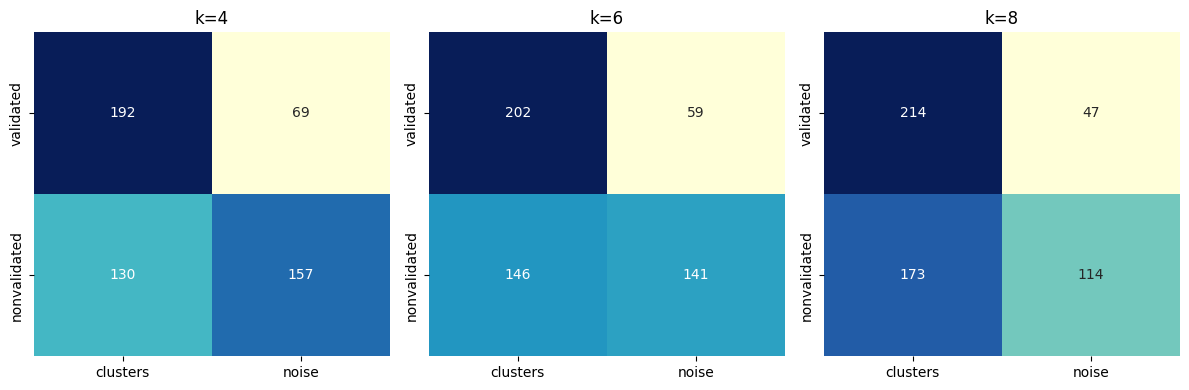

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = {}

for k in [4, 6, 8]:
    trb_data = pd.read_csv(f'tcrempnet_k{k}/vdjdb_tcremp_TRB_k{k}_tcremp_clusters.tsv', sep='\t')
    trb_data = trb_data[trb_data.clone_id.isin(vdjdb_ids)]

    val_counts = trb_data[trb_data.cdr3aa_beta.isin(tcrvdb_validated['cdr3_beta_aa'])].cluster_id.value_counts()
    nonval_counts = trb_data[trb_data.cdr3aa_beta.isin(tcrvdb_nonvalidated['cdr3_beta_aa'])].cluster_id.value_counts()

    # строим матрицу 2x2
    mat = pd.DataFrame({
        "clusters": [
            val_counts.drop(-1, errors="ignore").sum(),
            nonval_counts.drop(-1, errors="ignore").sum()
        ],
        "noise": [
            val_counts.get(-1, 0),
            nonval_counts.get(-1, 0)
        ]
    }, index=["validated", "nonvalidated"])

    results[k] = mat

# Рисуем три хитмапы в один ряд
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (k, mat) in zip(axes, results.items()):
    sns.heatmap(mat, annot=True, fmt="d", cmap="YlGnBu", ax=ax, cbar=False)
    ax.set_title(f"k={k}")

plt.tight_layout()
plt.show()


In [ ]:
# взять отдельно каждый эпитоп и сравнить с background ()
# посмотреть шаги для k и для epsilon напрямую
# декодер сейчас из 9k значений -- можно ли уменьшить?
# уменьшить k и посмотреть